# 社會網絡分析與地理應用 第六週作業

資訊工程學系 三年級 吳佳泰 S1254059

## 請利用student_course_enrollment的資料回答下列問題：

In [19]:
import networkx as nx
import pandas as pd
import numpy as np

df = pd.read_csv("student_course_enrollment.csv")
df

,Student,Course_1,Course_2,Course_3,Course_4,Course_5,Course_6,Course_7,Course_8,Course_9,Course_10
0,Student_1,0,1,0,0,0,1,0,0,0,1
1,Student_2,0,0,0,0,1,0,1,1,1,0
2,Student_3,1,0,1,1,1,1,1,1,1,1
3,Student_4,0,0,1,1,1,0,1,0,0,0
4,Student_5,0,0,1,1,1,1,1,0,1,1
5,Student_6,0,1,0,1,0,1,1,0,0,0
6,Student_7,0,0,0,0,0,1,1,0,1,1
7,Student_8,1,1,0,1,0,1,1,1,0,1
8,Student_9,0,1,0,1,0,0,1,0,1,1
9,Student_10,1,1,1,1,1,1,1,1,1,0


### 1. event規模有多大？

In [ ]:
df.drop("Student", axis=1, inplace=True)
n = df.values@df.values.T
print(np.mean(n.diagonal()))

3.75


### 2. event之間的密度高低為何？

In [27]:
print(np.mean(n[np.triu_indices(n.shape[0], k=1)]))

2.5157894736842104


### 3. 請計算每一個event節點的群聚係數
**hint**:可以用 `nx.from_numpy_array()` 產生網絡

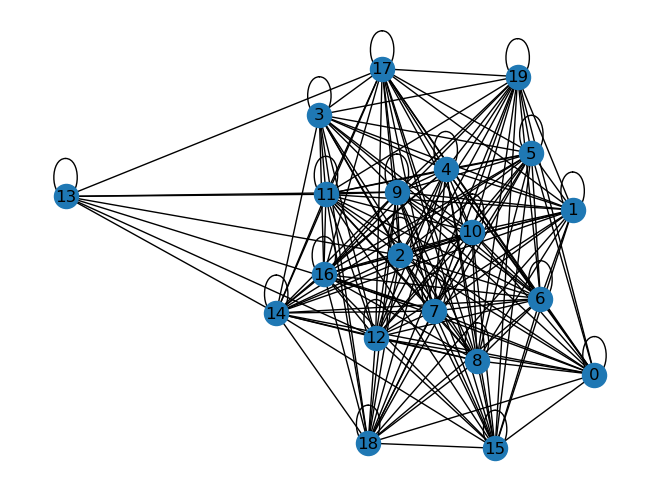

In [30]:
g = nx.from_numpy_array(n)
nx.draw(g, with_labels=True)

In [33]:
nx.clustering(g)

{0: 0.9833333333333333,
 1: 0.9779411764705882,
 2: 0.9005847953216374,
 3: 0.9833333333333333,
 4: 0.9673202614379085,
 5: 0.9673202614379085,
 6: 0.9673202614379085,
 7: 0.9005847953216374,
 8: 0.9673202614379085,
 9: 0.9005847953216374,
 10: 0.9673202614379085,
 11: 0.9005847953216374,
 12: 0.9005847953216374,
 13: 1.0,
 14: 0.9019607843137255,
 15: 0.9779411764705882,
 16: 0.9673202614379085,
 17: 0.9019607843137255,
 18: 0.9705882352941176,
 19: 0.9705882352941176}

### 4. 請問event的one-mode網絡是否存在clique結構？如果存在，請問最大的clique結構為何？

In [38]:
cliques = [x for x in nx.find_cliques(g)]
cliques_len = [len(x) for x in cliques]

if (len(cliques) == 0):
    print("None!")
else:
    print("Maximum clique length :", max(cliques_len))
    for i in cliques:
        if (len(i) == max(cliques_len)):
            print(i)

Maximum clique length : 15
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 0, 15, 17, 19]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 0, 15, 17, 14]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 0, 15, 18, 19]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 0, 15, 18, 14]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 3, 17, 19]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 3, 17, 14]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 3, 18, 19]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 3, 18, 14]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 15, 17, 19]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 15, 17, 14]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 15, 18, 19]
[2, 7, 9, 11, 12, 4, 5, 6, 8, 10, 16, 1, 15, 18, 14]
